In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
'''# Cell 2 — Update utils.py for 2-hand support
project_path = "/content/drive/MyDrive/CV_PROJECT"

utils_code = ''''''# utils.py
# Updated for 2-hand support.
# Extracts landmarks from up to 2 hands → 126 features total.
# If only 1 hand is visible, the missing hand is padded with zeros.
# This keeps input size consistent at 126 — model always gets same shape.

import cv2
import numpy as np
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision

HAND_CONNECTIONS = [
    (0,1),(1,2),(2,3),(3,4),
    (0,5),(5,6),(6,7),(7,8),
    (0,9),(9,10),(10,11),(11,12),
    (0,13),(13,14),(14,15),(15,16),
    (0,17),(17,18),(18,19),(19,20),
    (5,9),(9,13),(13,17)
]

# 63 values per hand × 2 hands = 126 total features
LANDMARKS_PER_HAND = 63
TOTAL_FEATURES     = 126


def download_model(save_path):
    import urllib.request
    url = "https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task"
    print("Downloading MediaPipe hand model...")
    urllib.request.urlretrieve(url, save_path)
    print(f"Model saved to: {save_path}")


def init_mediapipe(model_path, max_hands=2, detection_conf=0.7, tracking_conf=0.7):
    """
    Sets up MediaPipe with support for up to max_hands hands.
    Now defaults to 2.
    """
    base_options = mp_python.BaseOptions(model_asset_path=model_path)
    options = mp_vision.HandLandmarkerOptions(
        base_options=base_options,
        num_hands=max_hands,               # now supports 2
        min_hand_detection_confidence=detection_conf,
        min_hand_presence_confidence=tracking_conf,
        running_mode=mp_vision.RunningMode.IMAGE
    )
    return mp_vision.HandLandmarker.create_from_options(options)


def detect_hand(frame, detector):
    """
    Detects up to 2 hands in the frame.
    Draws landmarks for all detected hands.
    """
    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    mp_image  = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_frame)
    results   = detector.detect(mp_image)

    annotated = frame.copy()
    h, w = frame.shape[:2]

    if results.hand_landmarks:
        for hand in results.hand_landmarks:
            points = [(int(lm.x * w), int(lm.y * h)) for lm in hand]

            for s, e in HAND_CONNECTIONS:
                cv2.line(annotated, points[s], points[e], (0, 200, 0), 2)

            for (px, py) in points:
                cv2.circle(annotated, (px, py), 5, (0, 0, 255), -1)

    return results, annotated


def hand_detected(results):
    """Returns True if at least one hand was found."""
    return len(results.hand_landmarks) > 0


def extract_landmarks(results):
    """
    Extracts landmarks from up to 2 hands with CONSISTENT ORDER:
    [Left hand, Right hand]

    Returns 126 features:
    - Left hand (63)
    - Right hand (63)

    If a hand is missing → filled with zeros
    """

    if not hand_detected(results):
        return None

    # Prepare placeholders
    left_hand  = [0.0] * LANDMARKS_PER_HAND
    right_hand = [0.0] * LANDMARKS_PER_HAND

    # Loop through detected hands WITH handedness
    for hand, handedness in zip(results.hand_landmarks, results.handedness):

        label = handedness[0].category_name  # "Left" or "Right"

        features = []
        for lm in hand:
            features.extend([lm.x, lm.y, lm.z])

        if label == "Left":
            left_hand = features
        elif label == "Right":
            right_hand = features

    # Final consistent order: LEFT + RIGHT
    return left_hand + right_hand

def normalize_landmarks(landmarks):
    """
    Normalizes landmarks relative to the wrist of hand 1.
    Hand 1 wrist = index 0,1,2
    Hand 2 wrist = index 63,64,65

    If hand 2 is all zeros (not detected), normalization skips it.
    """
    if landmarks is None:
        return None

    # Normalize hand 1 relative to its own wrist
    wx1, wy1, wz1 = landmarks[0], landmarks[1], landmarks[2]
    hand1_norm = []
    for i in range(0, LANDMARKS_PER_HAND, 3):
        hand1_norm.extend([
            landmarks[i]   - wx1,
            landmarks[i+1] - wy1,
            landmarks[i+2] - wz1
        ])

    # Normalize hand 2 relative to its own wrist
    # but only if hand 2 was actually detected (not all zeros)
    hand2_raw = landmarks[LANDMARKS_PER_HAND:]
    hand2_norm = []

    if any(v != 0.0 for v in hand2_raw):
        wx2, wy2, wz2 = hand2_raw[0], hand2_raw[1], hand2_raw[2]
        for i in range(0, LANDMARKS_PER_HAND, 3):
            hand2_norm.extend([
                hand2_raw[i]   - wx2,
                hand2_raw[i+1] - wy2,
                hand2_raw[i+2] - wz2
            ])
    else:
        # Hand 2 not present — keep as zeros
        hand2_norm = [0.0] * LANDMARKS_PER_HAND

    return hand1_norm + hand2_norm
'''
'''
with open(f"{project_path}/utils.py", "w") as f:
    f.write(utils_code)

print("✅ utils.py updated for 2-hand support!")
print("   extract_landmarks() now returns 126 values")
print("   Missing hand is padded with zeros automatically")'''

'\nwith open(f"{project_path}/utils.py", "w") as f:\n    f.write(utils_code)\n\nprint("✅ utils.py updated for 2-hand support!")\nprint("   extract_landmarks() now returns 126 values")\nprint("   Missing hand is padded with zeros automatically")'

In [3]:
!pip install mediapipe==0.10.33 scikit-learn==1.6.1 -q

from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.insert(0, "/content/drive/MyDrive/CV_PROJECT")
print("✅ Session ready!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 100.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 10.5 MB/s eta 0:00:00
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Session ready!


In [4]:
'''# Cell 3 — Update model_loader.py
project_path = "/content/drive/MyDrive/CV_PROJECT"

model_loader_code = ''''''# model_loader.py
# Updated for 2-hand support.
# Model now expects 126 features instead of 63.

import pickle
import os
import numpy as np

CONFIDENCE_THRESHOLD = 0.6


def load_model(model_path):
    """Loads the trained model. Now expects 126 features."""
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Model not found at: {model_path}")

    with open(model_path, "rb") as f:
        model = pickle.load(f)

    print(f"Model loaded!")
    print(f"  Letters  : {list(model.classes_)}")
    print(f"  Features : {model.n_features_in_} (expected: 126 for 2-hand)")

    # Warn if model still expects 63 — means it needs retraining
    if model.n_features_in_ == 63:
        print("  WARNING: Model expects 63 features (single hand).")
        print("  Ask ML engineer to retrain with 2-hand data (126 features).")
    elif model.n_features_in_ == 126:
        print("  2-hand model confirmed!")

    return model


def predict_letter(model, landmarks):
    """
    Predicts ISL letter from 126 landmark features.
    Returns (letter, confidence) or (None, confidence) if below threshold.
    """
    if landmarks is None:
        return None, 0.0

    input_data = np.array(landmarks).reshape(1, -1)

    # Safety check — if feature count mismatches, warn clearly
    if input_data.shape[1] != model.n_features_in_:
        print(f"  Feature mismatch! Got {input_data.shape[1]}, "
              f"model expects {model.n_features_in_}")
        return None, 0.0

    probabilities    = model.predict_proba(input_data)[0]
    confidence       = float(max(probabilities))
    predicted_idx    = int(np.argmax(probabilities))
    predicted_letter = model.classes_[predicted_idx]

    if confidence >= CONFIDENCE_THRESHOLD:
        return predicted_letter, confidence
    else:
        return None, confidence
'''
'''
with open(f"{project_path}/model_loader.py", "w") as f:
    f.write(model_loader_code)

print("✅ model_loader.py updated!")'''

'\nwith open(f"{project_path}/model_loader.py", "w") as f:\n    f.write(model_loader_code)\n\nprint("✅ model_loader.py updated!")'

Model loaded!
  Letters  : [np.str_('A'), np.str_('B'), np.str_('C'), np.str_('D'), np.str_('E'), np.str_('F'), np.str_('G'), np.str_('H'), np.str_('I'), np.str_('J'), np.str_('K'), np.str_('L'), np.str_('M')]
  Features : 126 (expected: 126 for 2-hand)
  2-hand model confirmed!

📸 Show an ISL letter to the camera (A to M)...


<IPython.core.display.Javascript object>

⚠️ Low confidence: 36.0%


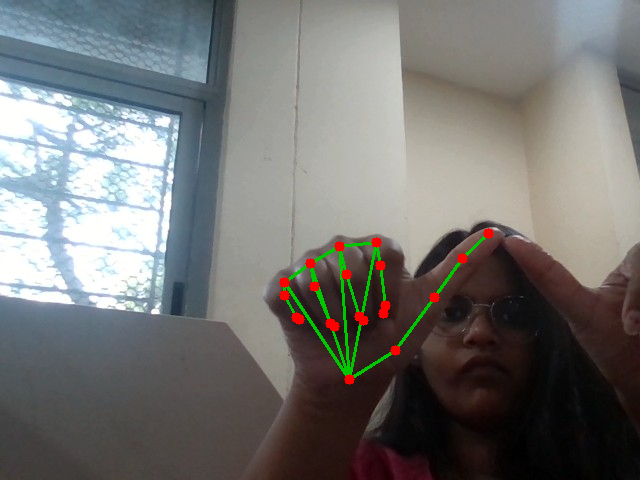

<IPython.core.display.Javascript object>

⚠️ Low confidence: 44.0%


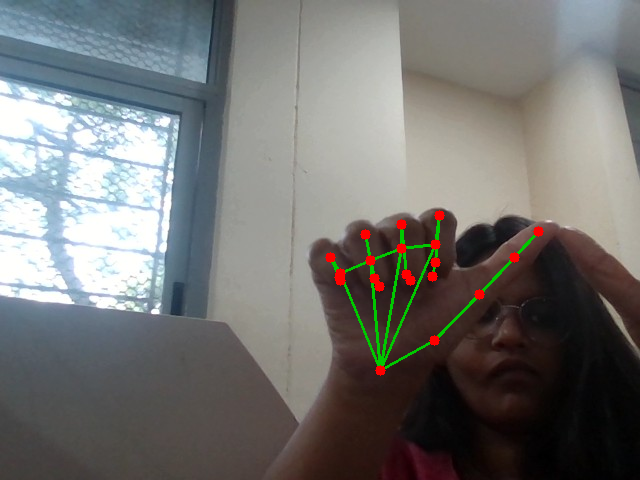

<IPython.core.display.Javascript object>

⚠️ No hand detected


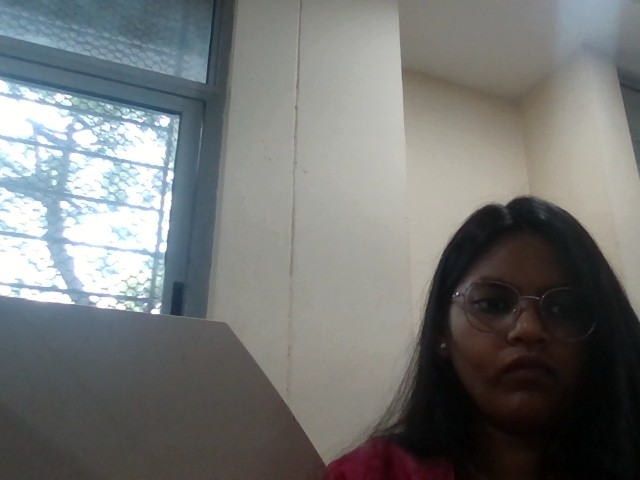

<IPython.core.display.Javascript object>

⚠️ No hand detected


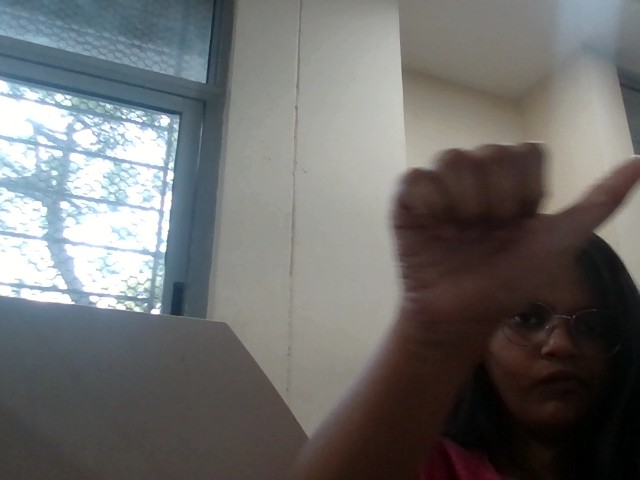

<IPython.core.display.Javascript object>

⚠️ Low confidence: 25.0%


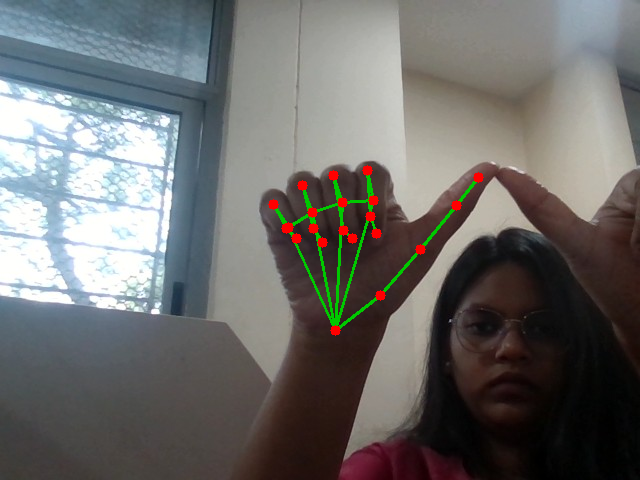

In [11]:
import importlib
import config, utils, model_loader
importlib.reload(model_loader)

from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import numpy as np
import cv2
from PIL import Image
import io

# ✅ FIXED BUFFER (deque instead of list)
from collections import deque, Counter

prediction_buffer = deque(maxlen=config.BUFFER_SIZE)

def get_stable_prediction(buffer):
    if len(buffer) == 0:
        return None
    count = Counter(buffer)
    return count.most_common(1)[0][0]

# =========================
# CAPTURE FRAME
# =========================
def capture_frame_from_colab():
    js_code = Javascript('''
        async function captureFrame() {
            const video = document.createElement('video');
            video.style.display = 'none';
            document.body.appendChild(video);
            const stream = await navigator.mediaDevices.getUserMedia({video:{width:640,height:480}});
            video.srcObject = stream;
            await new Promise(resolve => {
                video.onloadedmetadata = () => video.play().then(resolve);
            });
            await new Promise(resolve => setTimeout(resolve, 1500));
            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth || 640;
            canvas.height = video.videoHeight || 480;
            canvas.getContext('2d').drawImage(video, 0, 0);
            stream.getTracks().forEach(track => track.stop());
            video.remove();
            return canvas.toDataURL('image/jpeg', 0.9);
        }
        captureFrame()
            .then(r => element.textContent = r)
            .catch(e => element.textContent = 'ERROR:' + e.message);
    ''')
    display(js_code)
    result = eval_js('captureFrame()', timeout_sec=15)
    image_bytes = b64decode(result.split(',')[1])
    frame = np.array(Image.open(io.BytesIO(image_bytes)))
    return cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)

def show_frame(frame):
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    display(Image.fromarray(frame_rgb))

# =========================
# LOAD MODEL
# =========================
model = model_loader.load_model(config.MODEL_PATH)

# =========================
# INIT DETECTOR
# =========================
detector = utils.init_mediapipe(
    model_path=config.MEDIAPIPE_MODEL_PATH,
    max_hands=config.MAX_HANDS,
    detection_conf=config.DETECTION_CONFIDENCE,
    tracking_conf=config.TRACKING_CONFIDENCE
)

# =========================
# RUN PIPELINE
# =========================
print("\n📸 Show an ISL letter to the camera (A to M)...")

# OPTIONAL: clear buffer each run
prediction_buffer.clear()

# OPTIONAL: capture multiple frames for better stability
for _ in range(5):

    frame = capture_frame_from_colab()
    frame = cv2.resize(frame, (config.FRAME_WIDTH, config.FRAME_HEIGHT))

    results, annotated_frame = utils.detect_hand(frame, detector)

    # --- Hand check ---
    if not utils.hand_detected(results):
        print("⚠️ No hand detected")
        show_frame(annotated_frame)
        continue

    # --- Extract ---
    landmarks = utils.extract_landmarks(results)

    if landmarks is None or len(landmarks) != 126:
        print("⚠️ Invalid landmarks")
        show_frame(annotated_frame)
        continue

    # --- Normalize ---
    normalized = utils.normalize_landmarks(landmarks)

    if normalized is None or len(normalized) != 126:
        print("⚠️ Normalization failed")
        show_frame(annotated_frame)
        continue

    # --- Predict ---
    letter, confidence = model_loader.predict_letter(model, normalized)

    if letter is None:
        print(f"⚠️ Low confidence: {confidence*100:.1f}%")
        show_frame(annotated_frame)
        continue

    # --- Buffer update ---
    prediction_buffer.append(letter)

    # --- Stable prediction ---
    stable_letter = get_stable_prediction(prediction_buffer)

    print("\n" + "="*40)

    if stable_letter is None:
        print("⚠️ No stable prediction yet")
    else:
        print(f"🔤 Stable Prediction : {stable_letter}")
        print(f"📊 Confidence       : {confidence*100:.1f}%")

    print("="*40)

    show_frame(annotated_frame)

In [14]:
import importlib
import sys
sys.path.insert(0, "/content/drive/MyDrive/CV_PROJECT")

import config, utils, model_loader
importlib.reload(config)
importlib.reload(utils)
importlib.reload(model_loader)

print("=" * 45)
print("2-HAND SUPPORT VERIFICATION")
print("=" * 45)
print(f"MAX_HANDS setting     : {config.MAX_HANDS}")
print(f"Expected features     : {utils.TOTAL_FEATURES}")
print(f"Per hand              : {utils.LANDMARKS_PER_HAND}")

# Load current model and check
model = model_loader.load_model(config.MODEL_PATH)

print("\n" + "=" * 45)
if model.n_features_in_ == 126:
    print("✅ Everything is consistent! Ready for 2-hand.")
elif model.n_features_in_ == 63:
    print("⚠️  App side is ready for 2-hand.")
    print("   Waiting for ML engineer to retrain model.")
    print("   Current model (63 features) still works for A-M single hand.")
print("=" * 45)
# ```

# ---

# ## 📋 What to Tell Your ML Engineer

# Share this message with them:
# ```
# Hey! We've updated the app to support 2 hands.
# Please retrain the model with these changes:

# 1. Collect landmarks for BOTH hands in frame
# 2. Extract 126 features per sample:
#    - Hand 1: 63 values (21 landmarks × x,y,z)
#    - Hand 2: 63 values (21 landmarks × x,y,z)
#    - If only 1 hand visible → pad second hand with zeros
# 3. Train model on 126 features
# 4. Save as isl_model.pkl and upload to:
#    /content/drive/MyDrive/CV_PROJECT/model/isl_model.pkl

2-HAND SUPPORT VERIFICATION
MAX_HANDS setting     : 2
Expected features     : 126
Per hand              : 21
Model loaded!
  Letters  : [np.str_('A'), np.str_('B'), np.str_('C'), np.str_('D'), np.str_('E'), np.str_('F'), np.str_('G'), np.str_('H'), np.str_('I'), np.str_('J'), np.str_('K'), np.str_('L'), np.str_('M')]
  Features : 126 (expected: 126 for 2-hand)
  2-hand model confirmed!

✅ Everything is consistent! Ready for 2-hand.


In [15]:
# data_collector.py
# ML ENGINEER'S FILE
# Collects 2-hand landmark data for each ISL letter.
# Saves to CSV with 126 features + label.
# Run this once per letter, change LETTER each time.

import csv
import os
import sys

sys.path.insert(0, "/content/drive/MyDrive/CV_PROJECT")

from google.colab import drive
drive.mount('/content/drive')

from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import numpy as np
import cv2
from PIL import Image
import io
import config
import utils   # already updated by app engineer — has 2-hand support

# ─── SETTINGS ───────────────────────────────────────────
LETTER      = "A"    # change this for each letter
NUM_SAMPLES = 50     # minimum 50 per letter recommended
# ────────────────────────────────────────────────────────

project_path = "/content/drive/MyDrive/CV_PROJECT"
csv_path     = os.path.join(project_path, "data", "landmarks_data_2hand.csv")
os.makedirs(os.path.dirname(csv_path), exist_ok=True)


def capture_frame():
    js_code = Javascript('''
        async function captureFrame() {
            const video = document.createElement('video');
            video.style.display = 'none';
            document.body.appendChild(video);
            const stream = await navigator.mediaDevices.getUserMedia({
                video: {width:640, height:480}
            });
            video.srcObject = stream;
            await new Promise(resolve => {
                video.onloadedmetadata = () => video.play().then(resolve);
            });
            await new Promise(resolve => setTimeout(resolve, 1500));
            const canvas = document.createElement('canvas');
            canvas.width  = video.videoWidth  || 640;
            canvas.height = video.videoHeight || 480;
            canvas.getContext('2d').drawImage(video, 0, 0);
            stream.getTracks().forEach(t => t.stop());
            video.remove();
            return canvas.toDataURL('image/jpeg', 0.9);
        }
        captureFrame()
            .then(r => element.textContent = r)
            .catch(e => element.textContent = 'ERROR:' + e.message);
    ''')
    display(js_code)
    result      = eval_js('captureFrame()', timeout_sec=15)
    image_bytes = b64decode(result.split(',')[1])
    frame       = np.array(Image.open(io.BytesIO(image_bytes)))
    return cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)


def collect_samples(letter, num_samples):
    """
    Captures webcam frames, extracts 2-hand landmarks,
    and saves each as a row in the CSV file.

    Each row = 126 landmark values + 1 label = 127 columns total.
    If only 1 hand is visible, missing hand is auto-padded with zeros
    (this is handled inside utils.extract_landmarks automatically).
    """
    detector = utils.init_mediapipe(
        model_path    = config.MEDIAPIPE_MODEL_PATH,
        max_hands     = config.MAX_HANDS,       # now 2
        detection_conf= config.DETECTION_CONFIDENCE,
        tracking_conf = config.TRACKING_CONFIDENCE
    )

    saved  = 0
    failed = 0

    print(f"\n{'='*50}")
    print(f"  Collecting {num_samples} samples for: '{letter.upper()}'")
    print(f"  2-hand signs: show BOTH hands in frame")
    print(f"  1-hand signs: show only the signing hand")
    print(f"{'='*50}")

    while saved < num_samples:
        input(f"\n  [{saved+1}/{num_samples}] Make the sign → press Enter to capture")

        frame   = capture_frame()
        frame   = cv2.resize(frame, (config.FRAME_WIDTH, config.FRAME_HEIGHT))

        results, _ = utils.detect_hand(frame, detector)

        # extract_landmarks now returns 126 values
        # (pads missing hand with zeros automatically)
        landmarks  = utils.extract_landmarks(results)
        normalized = utils.normalize_landmarks(landmarks)

        if normalized is None:
            failed += 1
            print(f"  ⚠️  No hand detected! ({failed} failures so far)")
            continue

        # Sanity check — must always be 126 features
        if len(normalized) != 126:
            print(f"  ⚠️  Expected 126 features, got {len(normalized)} — skipping")
            continue

        # Count how many hands were actually visible
        hands_visible = len(results.hand_landmarks)

        # Write to CSV
        file_exists = os.path.exists(csv_path)
        with open(csv_path, "a", newline="") as f:
            writer = csv.writer(f)
            if not file_exists:
                # Header: f0 to f125 + label
                header = [f"f{i}" for i in range(126)] + ["label"]
                writer.writerow(header)
            writer.writerow(normalized + [letter.upper()])

        saved += 1
        print(f"  ✅ Saved! ({saved}/{num_samples}) — {hands_visible} hand(s) detected")

    print(f"\n🎉 Done! {saved} samples saved for '{letter.upper()}'")
    print(f"📄 CSV: {csv_path}")


# ─── RUN ────────────────────────────────────────────────
collect_samples(LETTER, NUM_SAMPLES)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

  2-hand signs: show BOTH hands in frame
  1-hand signs: show only the signing hand

  [1/50] Make the sign → press Enter to captureA


<IPython.core.display.Javascript object>

  ✅ Saved! (1/50) — 1 hand(s) detected

  [2/50] Make the sign → press Enter to captureA


<IPython.core.display.Javascript object>

  ⚠️  No hand detected! (1 failures so far)

  [2/50] Make the sign → press Enter to captureA


<IPython.core.display.Javascript object>

KeyboardInterrupt: 

In [16]:
# train_model.py
# ML ENGINEER'S FILE
# Trains a Random Forest on the collected 2-hand landmark data.
# Run this ONCE after collecting data for all letters.

import sys
sys.path.insert(0, "/content/drive/MyDrive/CV_PROJECT")

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import pickle
import os
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

project_path = "/content/drive/MyDrive/CV_PROJECT"
csv_path     = os.path.join(project_path, "data", "landmarks_data_2hand.csv")
model_path   = os.path.join(project_path, "model", "isl_model.pkl")


def load_and_validate_data(csv_path):
    """
    Loads the CSV and checks that:
    - It has exactly 126 feature columns
    - Each letter has enough samples
    - No missing values exist
    """
    print("📂 Loading data...")
    df = pd.read_csv(csv_path)

    print(f"✅ Loaded {len(df)} total samples")
    print(f"📊 Letters collected : {sorted(df['label'].unique())}")
    print(f"📊 Samples per letter:\n{df['label'].value_counts().sort_index()}\n")

    # Confirm feature count is 126
    feature_cols = [c for c in df.columns if c != "label"]
    if len(feature_cols) != 126:
        raise ValueError(
            f"Expected 126 features, got {len(feature_cols)}.\n"
            "Re-collect data using the updated utils.py (2-hand version)."
        )

    # Warn if any letter has fewer than 30 samples
    for letter, count in df['label'].value_counts().items():
        if count < 30:
            print(f"⚠️  Warning: '{letter}' only has {count} samples — recommend 50+")

    # Check for missing values
    if df.isnull().any().any():
        print("⚠️  Missing values found — dropping those rows")
        df = df.dropna()

    print(f"✅ Data validation passed! 126 features confirmed.\n")
    return df


def train_and_save(df, model_path):
    """
    Trains a Random Forest classifier and saves it as .pkl
    """
    feature_cols = [c for c in df.columns if c != "label"]
    X = df[feature_cols].values   # shape: (n_samples, 126)
    y = df["label"].values        # shape: (n_samples,)

    # 80% train, 20% test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size    = 0.2,
        random_state = 42,
        stratify     = y      # keeps class balance in both splits
    )

    print(f"🏋️  Training on {len(X_train)} samples...")
    print(f"🧪  Testing on  {len(X_test)} samples\n")

    # Random Forest — works well with landmark data
    model = RandomForestClassifier(
        n_estimators = 100,   # 100 trees
        max_depth    = 15,    # prevents overfitting on smaller datasets
        random_state = 42,
        n_jobs       = -1     # use all CPU cores — faster training
    )
    model.fit(X_train, y_train)

    # Evaluate
    y_pred   = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    print(f"🎯 Test Accuracy : {accuracy * 100:.1f}%")
    print(f"\n📋 Full Report:")
    print(classification_report(y_test, y_pred))

    # Confirm model expects 126 features
    print(f"✅ Model input size : {model.n_features_in_} features")
    print(f"✅ Letters known    : {list(model.classes_)}\n")

    # Save
    os.makedirs(os.path.dirname(model_path), exist_ok=True)
    with open(model_path, "wb") as f:
        pickle.dump(model, f)

    print(f"💾 Model saved → {model_path}")
    print("📤 Share isl_model.pkl with the App Engineer!")


# ─── RUN ────────────────────────────────────────────────
df = load_and_validate_data(csv_path)
train_and_save(df, model_path)
# ```

# ---

# ## 📋 Exact Order for the ML Engineer to Follow
# ```
# Step 1 → pip install mediapipe==0.10.33 scikit-learn pandas

# Step 2 → Mount Drive, set sys.path to CV_PROJECT

# Step 3 → Run data_collector.py with LETTER = "A" → collect 50 samples
#          Run again with LETTER = "B" → collect 50 samples
#          Repeat for every ISL letter they have

# Step 4 → Run train_model.py once → gets isl_model.pkl

# Step 5 → Confirm output says:
#             ✅ Model input size : 126 features
#             💾 Model saved → .../model/isl_model.pkl

# Step 6 → That's it — app engineer's code picks it up automatically

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📂 Loading data...


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/CV_PROJECT/data/landmarks_data_2hand.csv'

In [ ]:
# extract_from_images.py
# ML ENGINEER'S FILE — Step 1
# Reads every image from the dataset folder,
# extracts 2-hand landmarks using MediaPipe,
# and saves everything to a CSV file for training.

import os
import sys
import csv
import cv2
import numpy as np

sys.path.insert(0, "/content/drive/MyDrive/CV_PROJECT")

from google.colab import drive
drive.mount('/content/drive')

import config
import utils

# ─── SETTINGS — ML engineer updates these paths ──────────
DATASET_DIR = "/content/drive/MyDrive/CV_PROJECT/data_set"
CSV_OUTPUT  = "/content/drive/MyDrive/CV_PROJECT/data/landmarks_data_2hand.csv"
# ─────────────────────────────────────────────────────────

os.makedirs(os.path.dirname(CSV_OUTPUT), exist_ok=True)


def extract_landmarks_from_dataset(dataset_dir, csv_output):
    """
    Walks through every subfolder (each subfolder = one letter).
    For each image:
      - Runs MediaPipe hand detection
      - Extracts up to 2 hands → 126 landmark values
      - Normalizes relative to each hand's wrist
      - Saves row to CSV with label

    Images where no hand is detected are skipped and reported.
    """

    # Setup MediaPipe detector once — reuse for all images
    detector = utils.init_mediapipe(
        model_path     = config.MEDIAPIPE_MODEL_PATH,
        max_hands      = config.MAX_HANDS,        # 2
        detection_conf = config.DETECTION_CONFIDENCE,
        tracking_conf  = config.TRACKING_CONFIDENCE
    )

    # Count results for summary report
    total_saved   = 0
    total_skipped = 0
    skipped_files = []

    # Get all letter folders sorted alphabetically
    letter_folders = sorted([
        f for f in os.listdir(dataset_dir)
        if os.path.isdir(os.path.join(dataset_dir, f))
    ])

    print(f"📂 Found {len(letter_folders)} letter folders: {letter_folders}")
    print(f"📄 Output CSV: {csv_output}\n")

    # Open CSV file once — write all rows into it
    with open(csv_output, "w", newline="") as csv_file:
        writer = csv.writer(csv_file)

        # Write header — f0 to f125 are the 126 landmark features
        header = [f"f{i}" for i in range(126)] + ["label"]
        writer.writerow(header)

        # Loop through each letter folder
        for letter in letter_folders:
            letter_path = os.path.join(dataset_dir, letter)
            image_files = [
                f for f in os.listdir(letter_path)
                if f.lower().endswith((".jpg", ".jpeg", ".png"))
            ]

            letter_saved   = 0
            letter_skipped = 0

            for image_file in image_files:
                image_path = os.path.join(letter_path, image_file)

                # Load image with OpenCV
                frame = cv2.imread(image_path)
                if frame is None:
                    skipped_files.append(image_path)
                    letter_skipped += 1
                    continue

                # Resize to standard size
                frame = cv2.resize(frame, (config.FRAME_WIDTH, config.FRAME_HEIGHT))

                # Run MediaPipe detection
                landmarks  = utils.extract_landmarks(results)
                normalized = utils.normalize_landmarks(landmarks)

                if normalized is None:
                      continue

                if len(normalized) != 126:
                      continue

                X.append(normalized)
                y.append(label)
                normalized = utils.normalize_landmarks(landmarks)

                if normalized is None:
                    # No hand found in this image — skip it
                    skipped_files.append(image_path)
                    letter_skipped += 1
                    continue

                # Confirm 126 features
                if len(normalized) != 126:
                    letter_skipped += 1
                    continue

                # Write row: 126 values + letter label
                writer.writerow(normalized + [letter.upper()])
                letter_saved += 1

            total_saved   += letter_saved
            total_skipped += letter_skipped

            print(f"  {letter.upper()} → saved: {letter_saved}  skipped: {letter_skipped}")

    # Final summary
    print(f"\n{'='*45}")
    print(f"   Extraction complete!")
    print(f"   Total saved   : {total_saved}")
    print(f"   Total skipped : {total_skipped}")
    print(f"   CSV saved to  : {csv_output}")

    if skipped_files:
        print(f"\n⚠️  {len(skipped_files)} images had no hand detected.")
        print("   First 5 skipped files:")
        for f in skipped_files[:5]:
            print(f"     {f}")

    print(f"{'='*45}")
    print("➡️  Now run train_model.py")


# ─── RUN ─────────────────────────────────────────────────
extract_landmarks_from_dataset(DATASET_DIR, CSV_OUTPUT)

In [ ]:
# train_model.py
# ML ENGINEER'S FILE — Step 2
# Run this AFTER extract_from_images.py finishes.
# Trains Random Forest on the 126-feature CSV and saves isl_model.pkl

import sys
sys.path.insert(0, "/content/drive/MyDrive/CV_PROJECT")

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import pickle
import os
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

csv_path   = "/content/drive/MyDrive/CV_PROJECT/data/landmarks_data_2hand.csv"
model_path = "/content/drive/MyDrive/CV_PROJECT/model/isl_model.pkl"


def load_and_validate(csv_path):
    print("📂 Loading CSV...")
    df = pd.read_csv(csv_path)

    feature_cols = [c for c in df.columns if c != "label"]

    print(f"✅ Samples loaded  : {len(df)}")
    print(f"✅ Features per row: {len(feature_cols)} (expected 126)")
    print(f"✅ Letters found   : {sorted(df['label'].unique())}")
    print(f"\n📊 Samples per letter:")
    print(df['label'].value_counts().sort_index().to_string())

    # Must be 126 features
    if len(feature_cols) != 126:
        raise ValueError(
            f"Expected 126 features, got {len(feature_cols)}.\n"
            "Make sure extract_from_images.py used the updated utils.py"
        )

    # Warn on low sample counts
    for letter, count in df['label'].value_counts().items():
        if count < 30:
            print(f"\n⚠️  '{letter}' has only {count} samples — accuracy may be low")

    df = df.dropna()
    return df


def train_and_save(df, model_path):
    feature_cols = [c for c in df.columns if c != "label"]
    X = df[feature_cols].values
    y = df["label"].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size    = 0.2,
        random_state = 42,
        stratify     = y
    )

    print(f"\n🏋️  Training Random Forest...")
    print(f"   Train samples : {len(X_train)}")
    print(f"   Test samples  : {len(X_test)}")

    model = RandomForestClassifier(
        n_estimators = 100,
        max_depth    = 15,
        random_state = 42,
        n_jobs       = -1
    )
    model.fit(X_train, y_train)

    y_pred   = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    print(f"\n🎯 Accuracy : {accuracy * 100:.1f}%")
    print(f"\n📋 Full Report:\n{classification_report(y_test, y_pred)}")
    print(f"\n✅ Model input size : {model.n_features_in_} features")
    print(f"✅ Letters known    : {list(model.classes_)}")

    os.makedirs(os.path.dirname(model_path), exist_ok=True)
    with open(model_path, "wb") as f:
        pickle.dump(model, f)

    print(f"\n💾 Saved → {model_path}")
    print("📤 Send isl_model.pkl to the App Engineer!")


# ─── RUN ─────────────────────────────────────────────────
df = load_and_validate(csv_path)
train_and_save(df, model_path)
# ```

# ---

# ## 📋 Exact Order for ML Engineer
# ```
# Step 1 → Upload image dataset to Drive:
#          CV_PROJECT/dataset/A/  ← images of letter A
#          CV_PROJECT/dataset/B/  ← images of letter B
#          ... and so on

# Step 2 → Run setup cell:
#          !pip install mediapipe==0.10.33 scikit-learn==1.6.1 -q
#          Mount Drive + sys.path to CV_PROJECT

# Step 3 → Run extract_from_images.py
#          Wait for: "✅ Extraction complete!"

# Step 4 → Run train_model.py
#          Wait for: "💾 Saved → .../isl_model.pkl"

# Step 5 → Confirm output says:
#          ✅ Model input size : 126 features
#          🎯 Accuracy : XX%

# Step 6 → Done! App engineer's code picks it up automatically.